In [43]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [44]:

def load(name):
    k = 1
    while os.path.isfile(f"{name}_{k}.pkl"):
        k+=1
    k-=1
    with open(f'{name}_{k}.pkl','rb') as f:
        contentbis = pickle.load(f)
    print(f'{name}_{k}.pkl')

    return contentbis


N = 10000
folder = 'non_exclusive_axis_exploration2' 
name = f'{folder}/rand_run_{N}'
content_rand = load(name)
print(content_rand.keys())

non_exclusive_axis_exploration2/rand_run_10000_1.pkl
dict_keys(['memory_perf', 'memory_program', 'reward', 'tabular_view', 'interleaving'])


In [9]:
def content_o_alp_space(content):
    NN,F = content['tabular_view'].shape
    return np.concatenate((content['tabular_view'].reshape(N,1,F),content['reward'].reshape(N,1,F)),axis=1).transpose((2,0,1))

In [10]:
content_rewarf

(159, 10000, 2)


Text(0.5, 0, 'observable')

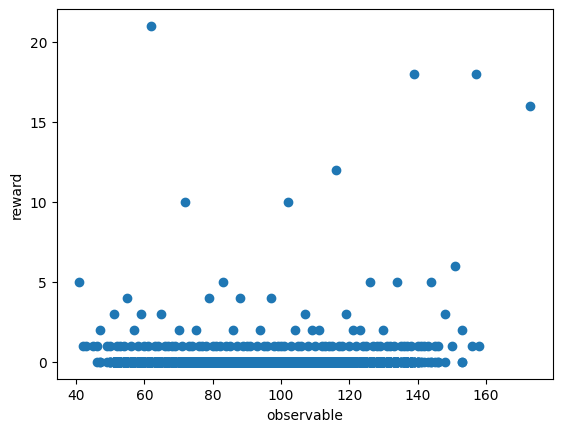

In [45]:
N = 10000
j = 1
plt.figure()
plt.scatter(o_alp_space[j,:N,0],o_alp_space[j,:N,1])
plt.ylabel('reward')
plt.xlabel('observable')

In [35]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
import time

In [36]:
def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize 
    # and one wants to minize bic score
    return -estimator.bic(X)

# One instantiate the gmm class and grid search

In [37]:
param_grid = {
    "n_components": range(2, 7),
    "covariance_type": ["diag", "full"],
}
grid_search = GridSearchCV(
    GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
)

In [38]:
import time

In [39]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import ParameterGrid
from joblib import Parallel, delayed
import numpy as np

def fit_gmm_for_dataset(dataset, params):
    """Fit GMM for a single dataset with given parameters and return the model"""
    gmm = GaussianMixture(**params)
    gmm.fit(dataset)
    return {
        'params': params,
        'bic': gmm.bic(dataset),
        'aic': gmm.aic(dataset),
        'converged': gmm.converged_,
        'model': gmm  # Return the fitted model!
    }

def parallel_gmm_search_with_models(datasets, param_grid, n_jobs=-1):
    """Perform parallel GMM grid search and return best models"""
    
    best_models = []
    all_results = []
    
    for i, dataset in enumerate(datasets):
        if i%50==0:
            print(f"Processing dataset {i+1}/{len(datasets)}")
        
        param_combinations = list(ParameterGrid(param_grid))
        
        # Parallel execution
        results = Parallel(n_jobs=n_jobs)(
            delayed(fit_gmm_for_dataset)(dataset, params)
            for params in param_combinations
        )
        
        # Find best model based on BIC (lower is better)
        best_result = min(results, key=lambda x: x['bic'])
        
        # Store the best model and its info
        best_models.append({
            'dataset_idx': i,
            'model': best_result['model'],  # The fitted GMM model
            'best_params': best_result['params'],
            'best_bic': best_result['bic'],
            'best_aic': best_result['aic']
        })
        
        all_results.append(results)
    
    return best_models, all_results

In [46]:
# Perform grid search and get best models
datasets = [np.random.randn(1000, 2) for _ in range(3)]
param_grid = {
    'n_components': [2,4,6],
    'covariance_type': ['full', 'diag'],
    'random_state': [42]
}
start_time = time.time()
best_models, all_results = parallel_gmm_search_with_models(datasets, param_grid, n_jobs=4)
print('end time',time.time() - start_time)
# Now use the best models for sampling
samples_per_dataset = 1
all_generated_samples = []

for i, best_model_info in enumerate(best_models):
    model = best_model_info['model']
    
    print(f"\n--- Best Model for Dataset {i} ---")
    print(f"Parameters: {best_model_info['best_params']}")
    print(f"BIC: {best_model_info['best_bic']:.2f}")
    print(f"Number of components: {model.n_components}")
    
    # Generate samples from the best distribution
    generated_samples, component_labels = model.sample(samples_per_dataset)
    all_generated_samples.append(generated_samples)
    
    print(f"Generated {len(generated_samples)} samples from dataset {i}")
    print(f"Sample mean: {np.mean(generated_samples, axis=0)}")
    print(f"Sample shape: {generated_samples.shape}")

# all_generated_samples now contains synthetic data from each best distribution

Processing dataset 1/3
end time 1.0892140865325928

--- Best Model for Dataset 0 ---
Parameters: {'covariance_type': 'diag', 'n_components': 2, 'random_state': 42}
BIC: 5794.88
Number of components: 2
Generated 1 samples from dataset 0
Sample mean: [-1.49859543  0.30235912]
Sample shape: (1, 2)

--- Best Model for Dataset 1 ---
Parameters: {'covariance_type': 'diag', 'n_components': 2, 'random_state': 42}
BIC: 5771.80
Number of components: 2
Generated 1 samples from dataset 1
Sample mean: [-0.32807741  0.31159496]
Sample shape: (1, 2)

--- Best Model for Dataset 2 ---
Parameters: {'covariance_type': 'diag', 'n_components': 2, 'random_state': 42}
BIC: 5729.31
Number of components: 2
Generated 1 samples from dataset 2
Sample mean: [-1.44618627  0.34416811]
Sample shape: (1, 2)


In [47]:
print(len(datasets),datasets[0].shape)

3 (1000, 2)


In [48]:
import dask
from dask.distributed import Client
import dask.bag as db

def setup_dask_cluster():
    """Set up a local Dask cluster"""
    client = Client(n_workers=4, threads_per_worker=1)
    return client

def dask_parallel_gmm(datasets, param_grid):
    """Using Dask for parallel processing"""
    client = setup_dask_cluster()
    
    param_combinations = list(ParameterGrid(param_grid))
    
    # Create lazy computations
    lazy_results = []
    for i, dataset in enumerate(datasets):
        for params in param_combinations:
            # Create lazy task
            result = dask.delayed(fit_gmm_for_dataset)(dataset, params)
            lazy_results.append((i, result))
    
    # Compute in parallel
    computed_results = dask.compute(*[r[1] for r in lazy_results])
    
    # Organize results
    final_results = {}
    for (dataset_idx, _), result in zip(lazy_results, computed_results):
        if dataset_idx not in final_results:
            final_results[dataset_idx] = []
        final_results[dataset_idx].append(result)
    
    return final_results

In [49]:
start = time.time()
results = dask_parallel_gmm(datasets, param_grid)
print(time.time()-start)

1.1833195686340332


In [50]:
import time

In [51]:
start_time = time.time()
best_models, all_results = parallel_gmm_search_with_models(o_alp_space, param_grid, n_jobs=4)
print('end time',time.time() - start_time)

Processing dataset 1/159
Processing dataset 51/159


/home/ludovic/directory_env/envir/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/ludovic/directory_env/envir/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/ludovic/directory_env/envir/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/ludovic/directory_env/envir/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit

Processing dataset 101/159


/home/ludovic/directory_env/envir/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/ludovic/directory_env/envir/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/ludovic/directory_env/envir/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/ludovic/directory_env/envir/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit

Processing dataset 151/159
end time 12.53846788406372


In [26]:
best_models[0]

{'dataset_idx': 0,
 'model': GaussianMixture(covariance_type='diag', n_components=6, random_state=42),
 'best_params': {'covariance_type': 'diag',
  'n_components': 6,
  'random_state': 42},
 'best_bic': np.float64(62331.223649474254),
 'best_aic': np.float64(62157.0389900124)}

In [27]:
o_alp_space.shape

(159, 3000, 2)

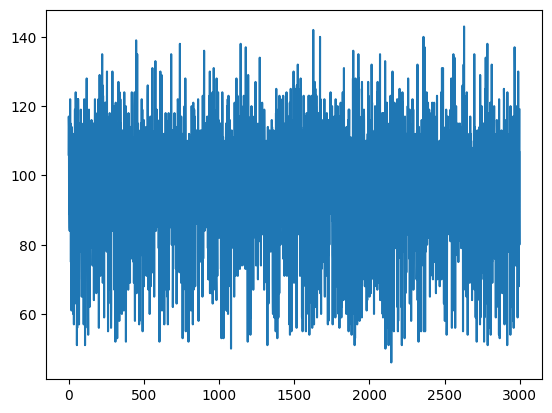

In [28]:
plt.plot(content_rand['tabular_view'][:,0])

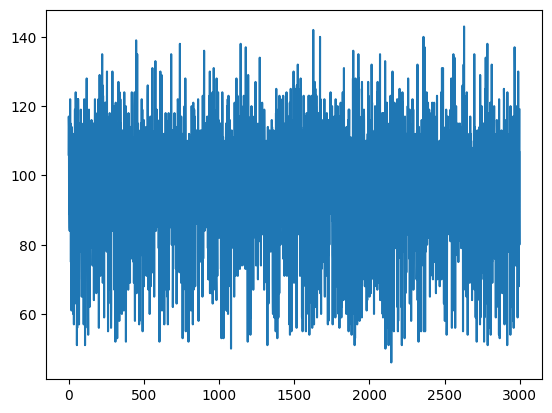

In [29]:
plt.plot(content_rand['memory_perf']['mutual']['time_core0'])

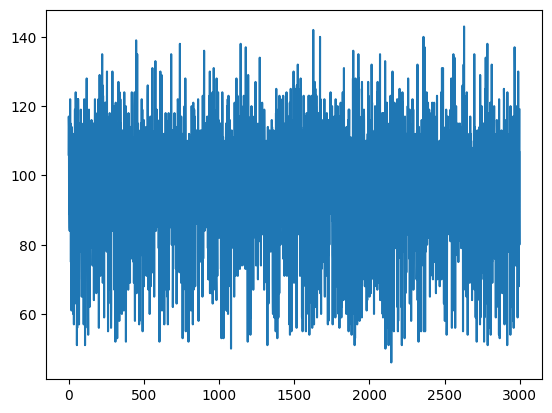

In [30]:
plt.plot(o_alp_space[0,:,0])

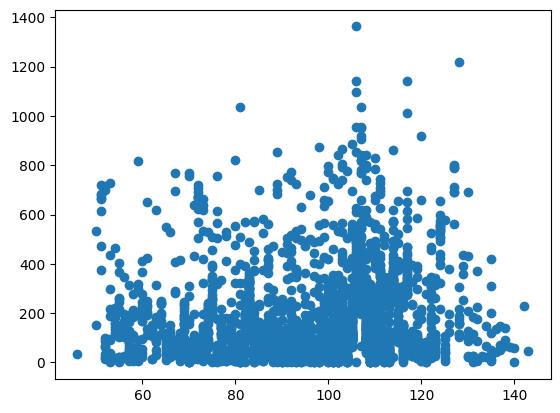

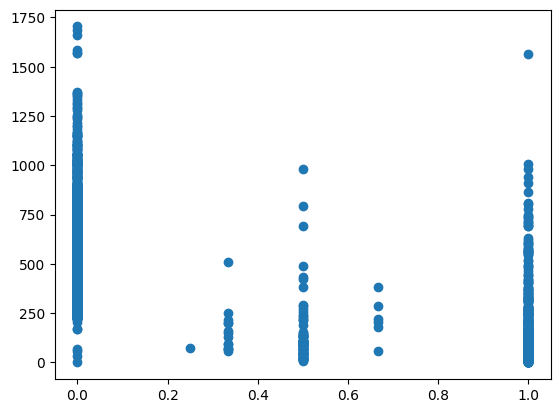

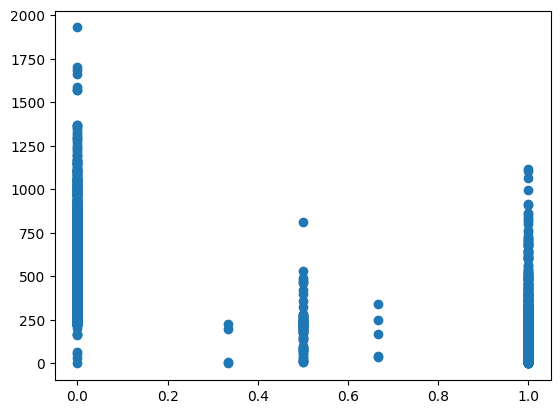

In [39]:
import matplotlib.pyplot as plt
for j in [0,5,10]:
    plt.figure()
    plt.scatter(o_alp_space[j,:,0],o_alp_space[j,:,1])
    plt.show()